# Energieprognose ischlstrom

Prognose der Gemeinschafts-Energiedaten (15-Minuten-Werte) für die Tage, die der
EEG-Faktura-Export noch nicht abdeckt — also *heute* und die nächsten ein bis zwei Wochen.

**Zielgrößen** (Meter Codes aus `metering_metercode`, Zusammenhang an den Gemeinschaftssummen geprüft):

| Größe | Bedeutung |
|---|---|
| `consumption` | Gesamtverbrauch lt. Messung aller teilnehmenden Zählpunkte |
| `generation` | Gesamte gemeinschaftliche Erzeugung (= „Anteil gemeinschaftliche Erzeugung", nur auf der anderen Seite gezählt) |
| `self_coverage` | Eigendeckung — der Teil der Gemeinschaftserzeugung, den die Mitglieder tatsächlich verbraucht haben |
| `surplus` | Gemeinschaftsüberschuss ins Netz, abgeleitet als `generation − self_coverage` |

`Anteil = Eigendeckung + Überschuss`; deshalb reichen drei Modelle, der Überschuss wird gerechnet.
Die Eigendeckung wird zusätzlich auf `min(Verbrauch, Erzeugung)` begrenzt, damit die Energiebilanz
der Prognose in sich stimmt.

**Wie es funktioniert**

Die Messdaten in `metering_measurement` kommen aus dem monatlichen EEG-Faktura-Export und sind
typischerweise drei bis fünf Wochen alt. Ein klassisches Lastprognosemodell mit Lags der letzten
Stunden/Tage ist damit unbrauchbar. Stattdessen lernt das Modell den Zusammenhang

> (Kalender, Sonnenstand, Wetter) → Energie **je aktivem Zählpunkt**

aus rund zwei Jahren Historie und wendet ihn auf die *Wettervorhersage* an (Open-Meteo, dieselbe
Quelle wie die Notebooks in `weather/`).

Zwei Dinge sind dabei wichtig:

1. **Normierung je Zählpunkt** — die Gemeinschaft ist von 4 auf über 420 Zählpunkte gewachsen.
   Absolute Summen werden vom Mitgliederwachstum dominiert, nicht vom Wetter. Deshalb wird je
   Zählpunkt modelliert und die Prognose mit der fortgeschriebenen Zählpunktanzahl hochskaliert.
2. **Datenqualität** — manche Exporte sind unvollständig geliefert (Zeilen vorhanden, aber ein
   großer Teil der Zählpunkte durchgehend 0). Solche Tage werden erkannt und aus Training und
   Bewertung ausgeschlossen.

Die gesamte Logik steckt in [eeg_forecast.py](eeg_forecast.py), dieses Notebook ist die Bedienung dazu.

In [1]:
%pip install -q "psycopg[binary,pool]" pandas numpy scikit-learn matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eeg_forecast as ef

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (14, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Daten laden

`build_frame()` liest die Messdaten aus der Middleware-DB, holt Wetter-Historie und -Vorhersage von
Open-Meteo und baut daraus einen 15-Minuten-Datenrahmen mit allen Features.

`refresh=True` erzwingt das Neuladen (DB-Abfrage ≈ 40 s). Ohne `refresh` werden die Dateien in
`cache/` verwendet — die Wettervorhersage wird trotzdem alle 3 Stunden neu geholt.

**Nach jedem neuen EEG-Faktura-Import `refresh=True` setzen.**

In [3]:
frame = ef.build_frame(refresh=False)

last_day = ef.last_complete_day(frame)
today = pd.Timestamp.now(tz=ef.TZ).normalize()
print(f"vollständige Daten bis   : {last_day.date()}")
print(f"Datenlücke bis heute     : {(today.tz_localize(None) - last_day).days} Tage")
print(f"Trainingsintervalle      : {int(frame.complete.sum()):,}")
print(f"Features                 : {len(ef.feature_columns(frame))}")
frame.tail(3)

vollständige Daten bis   : 2026-07-06
Datenlücke bis heute     : 22 Tage
Trainingsintervalle      : 73,152
Features                 : 45


,quarter_of_day,tod_sin,tod_cos,tod_sin2,tod_cos2,day_of_week,is_weekend,is_holiday,is_off_day,doy_sin,doy_cos,doy_sin2,doy_cos2,month,solar_elevation,solar_azimuth,clear_sky_ghi,is_day,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,wind_speed_10m,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance,sunshine_duration,clear_sky_index,temp_24h,temp_min_24h,temp_max_24h,heating_degrees,cooling_degrees,radiation_24h,radiation_3h,snow_cover,n_cons,n_gen,complete,consumption_total,consumption_pp,generation_total,generation_pp,self_coverage_total,self_coverage_pp,allocated_total,allocated_pp,surplus_total,surplus_pp
2026-08-12 23:30:00+00:00,6,0.382683,0.923880,0.707107,0.707107,3,0,0,0,-0.666089,-0.745872,0.993635,0.112651,8,-27.407115,5.313052,0.0,0,16.2,95.0,15.4,17.2,0.3,0.0,0.0,0.0,83.0,0.0,24.0,81.0,6.1,0.0,0.0,0.0,0.0,0.0,0.0,18.666667,16.2,22.5,0.0,0.0,93.352941,0.0,0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-12 23:45:00+00:00,7,0.442289,0.896873,0.793353,0.608761,3,0,0,0,-0.666089,-0.745872,0.993635,0.112651,8,-27.087604,9.377312,0.0,0,16.2,95.0,15.4,17.2,0.3,0.0,0.0,0.0,83.0,0.0,24.0,81.0,6.1,0.0,0.0,0.0,0.0,0.0,0.0,18.680000,16.2,22.5,0.0,0.0,93.540000,0.0,0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-08-13 00:00:00+00:00,8,0.500000,0.866025,0.866025,0.500000,3,0,0,0,-0.666089,-0.745872,0.993635,0.112651,8,-26.592282,13.404630,0.0,0,16.2,95.0,15.4,17.2,0.3,0.0,0.0,0.0,83.0,0.0,24.0,81.0,6.1,0.0,0.0,0.0,0.0,0.0,0.0,18.690816,16.2,22.5,0.0,0.0,93.561224,0.0,0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Datenqualität und Wachstum

Links: Energie je Zählpunkt und Tag (das, was tatsächlich modelliert wird).
Rechts: Anzahl der Zählpunkte, die Daten liefern. Rot markierte Tage sind unvollständig geliefert
und werden nicht verwendet.

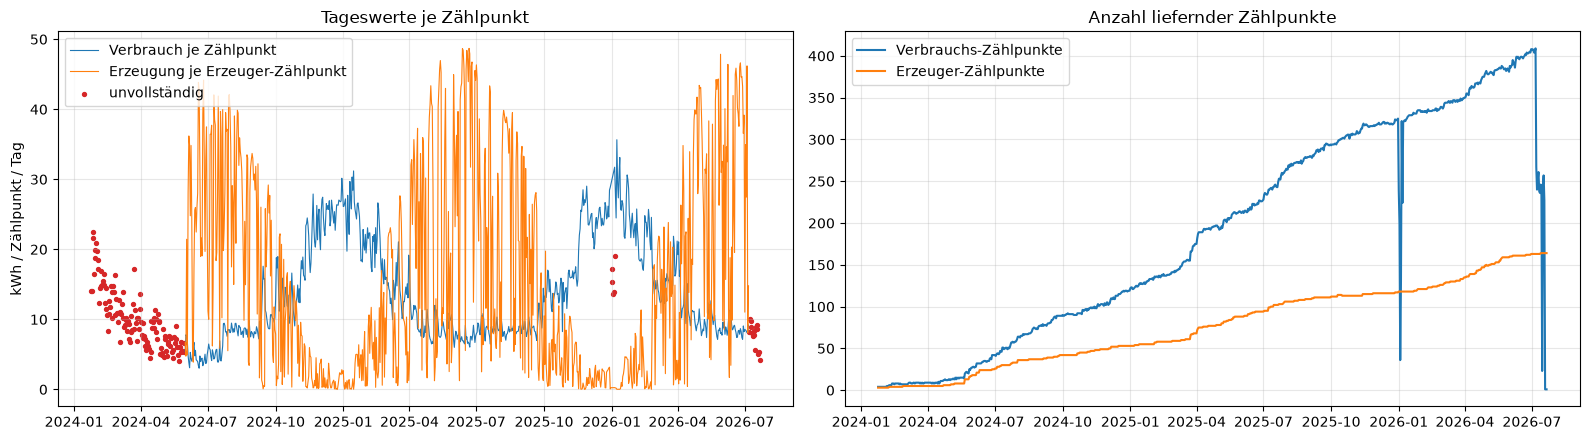

In [4]:
daily = frame.copy()
daily["day"] = pd.to_datetime(daily.index.tz_convert(ef.TZ).date)
per_day = daily.groupby("day").agg(
    consumption_pp=("consumption_pp", "sum"),
    generation_pp=("generation_pp", "sum"),
    n_cons=("n_cons", "max"),
    n_gen=("n_gen", "max"),
    complete=("complete", "max"),
).dropna(subset=["n_cons"])

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
ok = per_day[per_day.complete]
bad = per_day[~per_day.complete]
axes[0].plot(ok.index, ok.consumption_pp, lw=0.8, label="Verbrauch je Zählpunkt")
axes[0].plot(ok.index, ok.generation_pp, lw=0.8, label="Erzeugung je Erzeuger-Zählpunkt")
axes[0].scatter(bad.index, bad.consumption_pp, s=8, color="tab:red", label="unvollständig")
axes[0].set_ylabel("kWh / Zählpunkt / Tag")
axes[0].set_title("Tageswerte je Zählpunkt")
axes[0].legend()

axes[1].plot(per_day.index, per_day.n_cons, label="Verbrauchs-Zählpunkte")
axes[1].plot(per_day.index, per_day.n_gen, label="Erzeuger-Zählpunkte")
axes[1].set_title("Anzahl liefernder Zählpunkte")
axes[1].legend()
plt.tight_layout()

## 2. Backtest

Rollierende Auswertung: das Modell wird jeweils nur auf der Vergangenheit trainiert und muss die
darauffolgenden 14 Tage vorhersagen — genau die Situation im Echtbetrieb.

Verglichen wird gegen eine naive Referenz (Mittelwert je Wochentag × Viertelstunde aus den letzten
28 vollständigen Tagen). `skill_*_pct` ist die prozentuale Fehlerreduktion gegenüber dieser
Referenz, positiv = besser.

Laufzeit ≈ 2 Minuten.

In [5]:
results = ef.backtest(frame, folds=6, horizon_days=14)
summary = ef.backtest_summary(results)
summary[["folds", "model_nmae_pct", "base_nmae_pct", "model_daily_nmae_pct",
         "base_daily_nmae_pct", "skill_vs_baseline_pct", "skill_daily_pct"]]

fold 1/6: train < 2026-04-13, test 1344 intervals


fold 2/6: train < 2026-04-27, test 1344 intervals


fold 3/6: train < 2026-05-11, test 1344 intervals


fold 4/6: train < 2026-05-25, test 1344 intervals


fold 5/6: train < 2026-06-08, test 1344 intervals


fold 6/6: train < 2026-06-22, test 1344 intervals


,folds,model_nmae_pct,base_nmae_pct,model_daily_nmae_pct,base_daily_nmae_pct,skill_vs_baseline_pct,skill_daily_pct
target,,,,,,,
consumption,6,13.25,25.54,6.53,21.50,48.14,69.61
generation,6,23.18,56.82,13.83,49.05,59.20,71.81
self_coverage,6,26.27,38.29,13.94,27.20,31.38,48.74


Text(0.5, 0, 'Trainingsende')

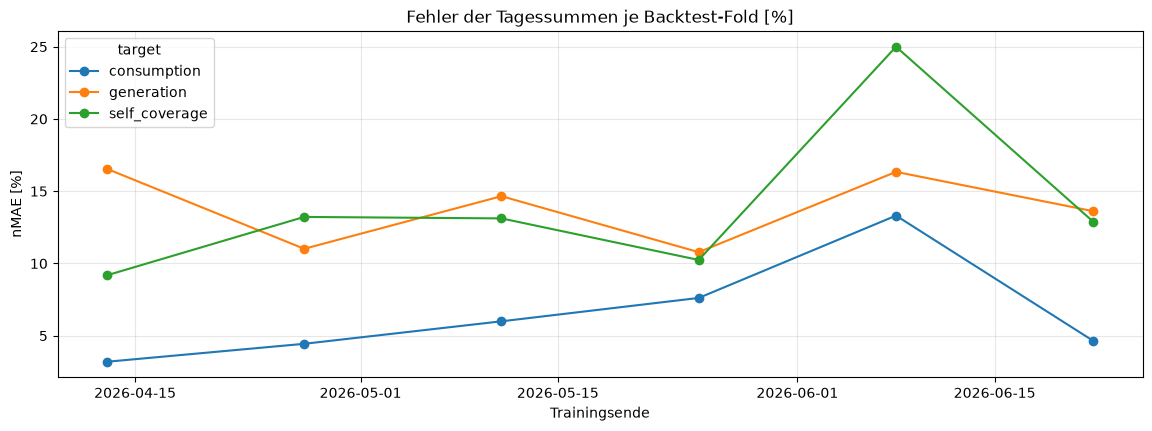

In [6]:
# Fehler je Fold (Tagessummen) — zeigt, ob einzelne Zeiträume ausreißen
pivot = results.pivot(index="cutoff", columns="target", values="model_daily_nmae_pct")
pivot.plot(marker="o", title="Fehler der Tagessummen je Backtest-Fold [%]")
plt.ylabel("nMAE [%]")
plt.xlabel("Trainingsende")

### Prognose vs. Wirklichkeit im letzten Backtest-Fenster

Sanity-Check: Modell auf allem vor `cutoff` trainiert, danach 14 Tage vorhergesagt und mit den
tatsächlichen Werten verglichen.

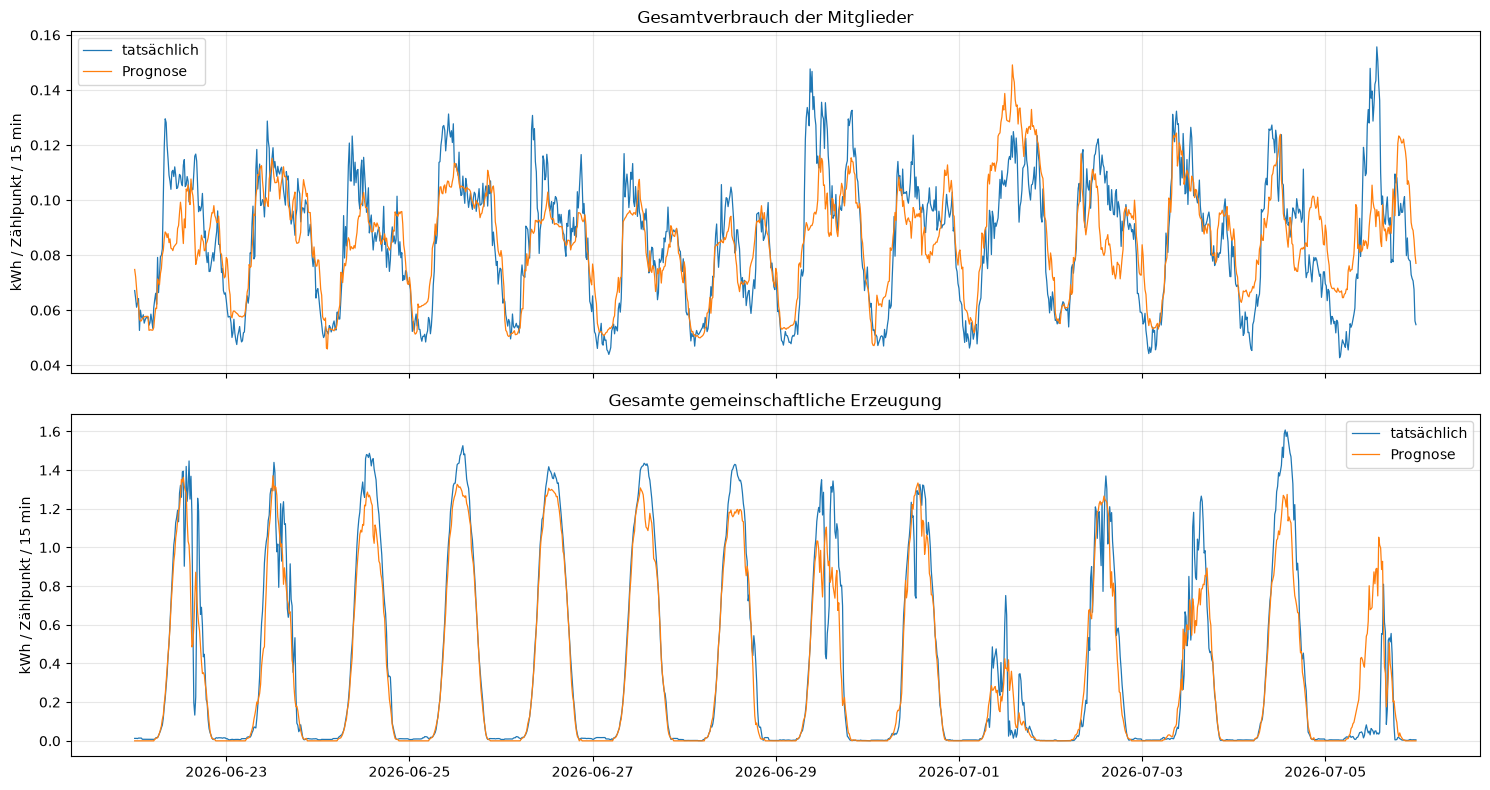

In [7]:
cutoff_day = pd.Timestamp(results.cutoff.max())
cutoff = cutoff_day.tz_localize(ef.TZ).tz_convert("UTC")
check_models = ef.train(frame, until=cutoff, quantiles=())

window = frame.index[(frame.index >= cutoff) & (frame.index < cutoff + pd.Timedelta(days=14))]
window = window[frame.loc[window, "complete"].to_numpy()]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
for ax, key in zip(axes, ["consumption", "generation"]):
    actual = frame.loc[window, f"{key}_pp"]
    predicted = ef._predict_pp(check_models, key, frame, window)["mean"]
    ax.plot(window.tz_convert(ef.TZ), actual, lw=0.9, label="tatsächlich")
    ax.plot(window.tz_convert(ef.TZ), predicted, lw=0.9, label="Prognose")
    ax.set_title(ef.TARGETS_BY_KEY[key].label)
    ax.set_ylabel("kWh / Zählpunkt / 15 min")
    ax.legend()
plt.tight_layout()

## 3. Modell trainieren und Einflussgrößen

Jetzt auf allen vollständigen Daten trainieren. Pro Zielgröße entstehen drei Modelle:
Punktprognose sowie 10 %- und 90 %-Quantil für das Prognoseband.

In [8]:
models = ef.train(frame)
for key, entry in models.items():
    print(f"{key:12s} n_train={entry['n_train']:6d}  Level-Korrektur={entry['scale']:.3f}")

consumption  n_train= 73144  Level-Korrektur=1.323
generation   n_train= 73144  Level-Korrektur=0.927
self_coverage n_train= 73144  Level-Korrektur=1.319


Text(0.5, 0, 'Verschlechterung bei Permutation')

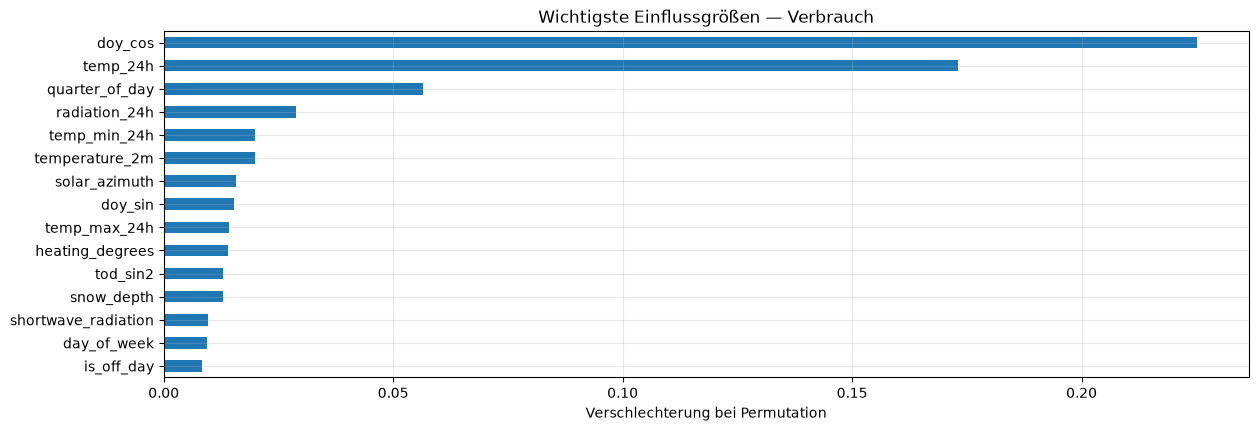

In [9]:
importance = ef.feature_importance(frame, models, "consumption")
importance.head(15).iloc[::-1].plot.barh(title="Wichtigste Einflussgrößen — Verbrauch")
plt.xlabel("Verschlechterung bei Permutation")

Text(0.5, 0, 'Verschlechterung bei Permutation')

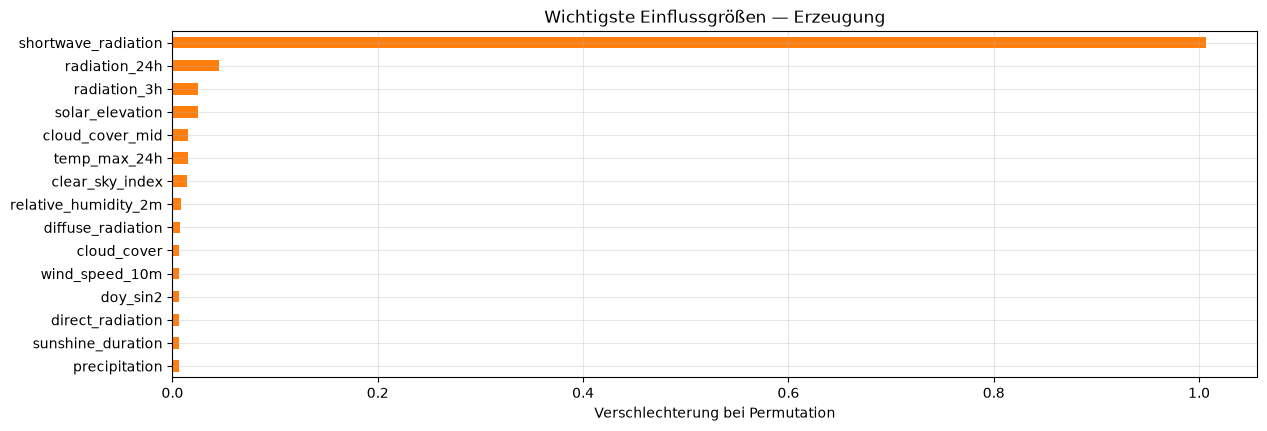

In [10]:
importance_gen = ef.feature_importance(frame, models, "generation")
importance_gen.head(15).iloc[::-1].plot.barh(title="Wichtigste Einflussgrößen — Erzeugung", color="tab:orange")
plt.xlabel("Verschlechterung bei Permutation")

## 4. Prognose

Ab dem ersten fehlenden Tag (also inklusive der Lücke bis heute) für die nächsten Tage.
`days` zählt ab `start`; um nur ab heute zu rechnen: `ef.forecast(frame, models, start=today, days=10)`.

In [11]:
prediction = ef.forecast(frame, models, days=30)
daily_forecast = ef.daily_summary(prediction)

columns = ["consumption_kwh", "generation_kwh", "self_coverage_kwh", "surplus_kwh",
           "coverage_pct", "n_cons", "n_gen"]
daily_forecast[columns].rename(columns={
    "consumption_kwh": "Verbrauch [kWh]",
    "generation_kwh": "Erzeugung [kWh]",
    "self_coverage_kwh": "Eigendeckung [kWh]",
    "surplus_kwh": "Überschuss [kWh]",
    "coverage_pct": "Deckung [%]",
    "n_cons": "Zählpunkte",
    "n_gen": "Erzeuger",
})

,Verbrauch [kWh],Erzeugung [kWh],Eigendeckung [kWh],Überschuss [kWh],Deckung [%],Zählpunkte,Erzeuger
local_time,,,,,,,
2026-07-07 00:00:00+02:00,3896.9,4598.5,1932.8,2665.7,49.6,410,169
2026-07-08 00:00:00+02:00,4681.8,1364.9,1214.7,150.2,25.9,411,169
2026-07-09 00:00:00+02:00,4487.0,3865.6,1748.1,2117.4,39.0,412,170
2026-07-10 00:00:00+02:00,3578.0,7291.9,2027.5,5264.4,56.7,412,170
2026-07-11 00:00:00+02:00,3143.3,6850.7,1792.4,5058.3,57.0,413,170
2026-07-12 00:00:00+02:00,3396.8,6076.3,1869.7,4206.7,55.0,413,171
2026-07-13 00:00:00+02:00,3477.3,7386.0,1882.5,5503.5,54.1,414,171
2026-07-14 00:00:00+02:00,3330.6,5344.4,1662.2,3682.2,49.9,414,171
2026-07-15 00:00:00+02:00,3491.4,5155.5,1673.5,3481.9,47.9,415,172


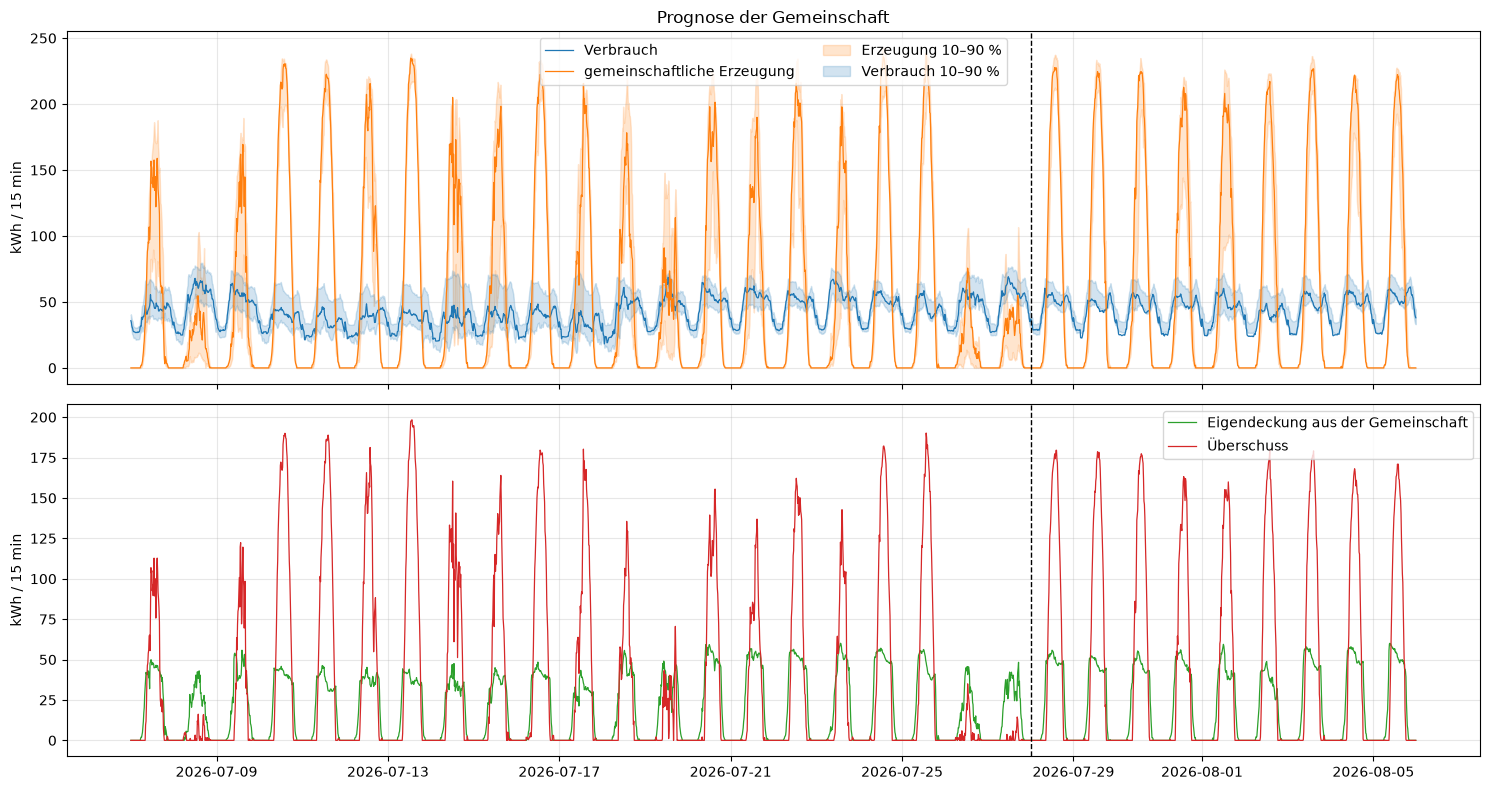

In [12]:
local_index = prediction.local_time

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axes[0].plot(local_index, prediction.consumption_kwh, lw=0.9, label="Verbrauch")
axes[0].plot(local_index, prediction.generation_kwh, lw=0.9, label="gemeinschaftliche Erzeugung")
axes[0].fill_between(local_index, prediction.generation_kwh_q10, prediction.generation_kwh_q90,
                     alpha=0.2, color="tab:orange", label="Erzeugung 10–90 %")
axes[0].fill_between(local_index, prediction.consumption_kwh_q10, prediction.consumption_kwh_q90,
                     alpha=0.2, color="tab:blue", label="Verbrauch 10–90 %")
axes[0].set_ylabel("kWh / 15 min")
axes[0].set_title("Prognose der Gemeinschaft")
axes[0].legend(ncol=2)

axes[1].plot(local_index, prediction.self_coverage_kwh, lw=0.9, color="tab:green",
             label="Eigendeckung aus der Gemeinschaft")
axes[1].plot(local_index, prediction.surplus_kwh, lw=0.9, color="tab:red", label="Überschuss")
axes[1].set_ylabel("kWh / 15 min")
axes[1].legend()
plt.tight_layout()

today = pd.Timestamp.now(tz=ef.TZ).normalize()
for ax in axes:
    ax.axvline(today, color="k", ls="--", lw=1)

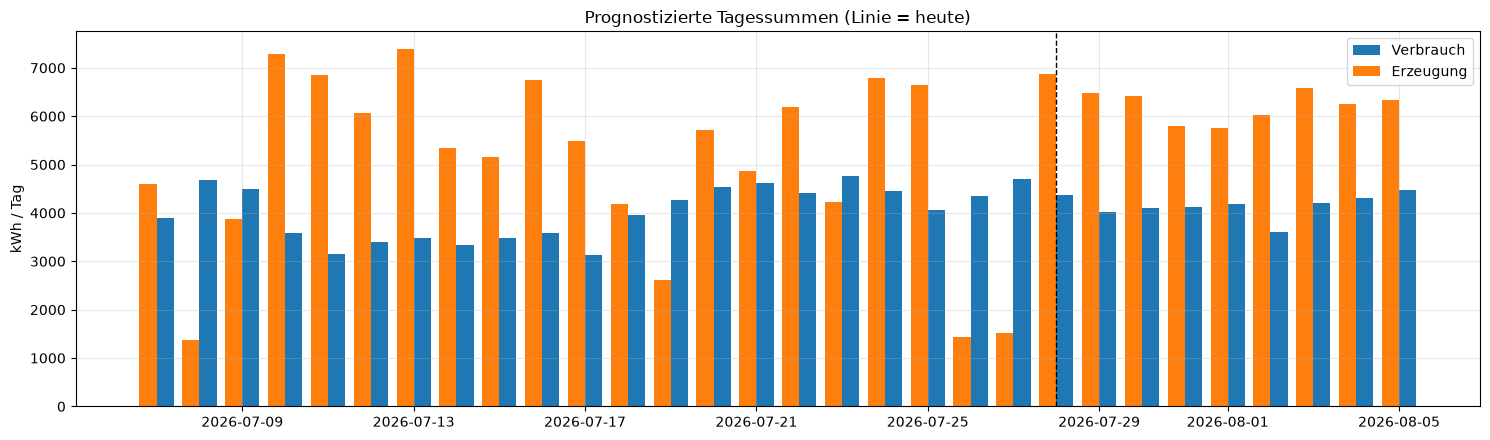

In [13]:
# Tagessummen als Balken: Prognose im Vergleich zum letzten vollständigen Monat
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.bar(daily_forecast.index, daily_forecast.consumption_kwh, width=0.4, align="edge",
       label="Verbrauch", color="tab:blue")
ax.bar(daily_forecast.index, daily_forecast.generation_kwh, width=-0.4, align="edge",
       label="Erzeugung", color="tab:orange")
ax.axvline(pd.Timestamp.now(tz=ef.TZ).normalize(), color="k", ls="--", lw=1)
ax.set_ylabel("kWh / Tag")
ax.set_title("Prognostizierte Tagessummen (Linie = heute)")
ax.legend()
plt.tight_layout()

### Heute im Detail

Prognose 2026-07-28
  Verbrauch                            4371 kWh   (3854 – 5067)
  gemeinschaftliche Erzeugung          6866 kWh   (5888 – 7420)
  davon von Mitgliedern genutzt        2264 kWh   (1971 – 2335)
  Überschuss ins Netz                  4602 kWh   (3768 – 5156)
  Deckungsgrad                         51.8 %


Text(0, 0.5, 'kWh / 15 min')

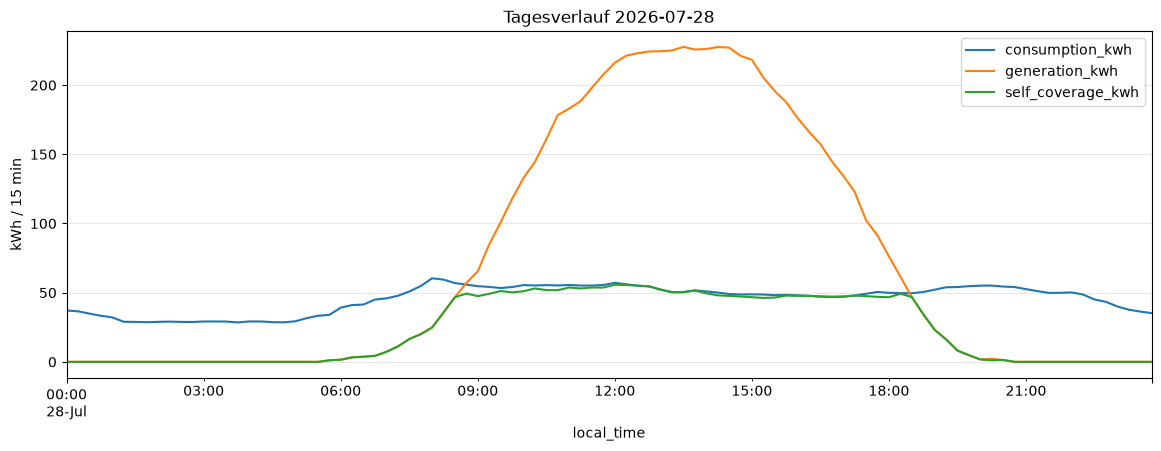

In [14]:
today = pd.Timestamp.now(tz=ef.TZ).normalize()
mask = (prediction.local_time >= today) & (prediction.local_time < today + pd.Timedelta(days=1))
today_frame = prediction[mask]

print(f"Prognose {today.date()}")
for key, label in [("consumption", "Verbrauch"), ("generation", "gemeinschaftliche Erzeugung"),
                   ("self_coverage", "davon von Mitgliedern genutzt"), ("surplus", "Überschuss ins Netz")]:
    total = today_frame[f"{key}_kwh"].sum()
    low, high = today_frame[f"{key}_kwh_q10"].sum(), today_frame[f"{key}_kwh_q90"].sum()
    print(f"  {label:32s} {total:8.0f} kWh   ({low:.0f} – {high:.0f})")
print(f"  {'Deckungsgrad':32s} "
      f"{100 * today_frame.self_coverage_kwh.sum() / today_frame.consumption_kwh.sum():8.1f} %")

today_frame.set_index(today_frame.local_time)[["consumption_kwh", "generation_kwh", "self_coverage_kwh"]].plot(
    title=f"Tagesverlauf {today.date()}")
plt.ylabel("kWh / 15 min")

## 5. Export

15-Minuten-Prognose und Tagessummen als CSV — z. B. für die Website oder eine Auswertung.

In [15]:
prediction.to_csv(ef.CACHE_DIR / "forecast_15min.csv")
daily_forecast.to_csv(ef.CACHE_DIR / "forecast_daily.csv")
print("geschrieben nach", ef.CACHE_DIR)

geschrieben nach /home/martin/Workspace/Energiegemeinschaft/notebooks/forecast/cache
